# Tabular Kaggle Project

Guideline for steps for the Kaggle Tabular Project. You will "turn in" a GitHub repository, modeled after [Project Template](https://github.com/UTA-DataScience/ProjectTempate) on the day of the final, Friday, May 2 at 11 – 1:30 pm. During the final period we will have about 5 minutes to go over your project and your results.

You can find a list of possible Tabular datasets here on [Excel File in Teams](https://mavsuta.sharepoint.com/:x:/r/teams/Course_2252_data_3402_001-NLyiqHJ5btv8Y/Shared%20Documents/General/Kaggle%20Tabular%20Datasets.xlsx?d=w34cdd3378d1146a2ab63700189a8c5b5&csf=1&web=1&e=6ASD5s). You are not limited to these datasets. If you find a Kaggle challenge not listed that you would like to attempt, please go check with Dr. Farbin to make sure it is viable.

This notebook outlines the steps you should follow. The file(s) in the GitHub repository should contain these steps. Note that you will be only considering classification projects.

## Define Project

* Provide Project link.
* Short paragraph describing the challenge. 
* Briefly describe the data.


## Data Loading and Initial Look

* Load the data. 
* Count the number of rows (data points) and features.
* Any missing values? 
* Make a table, where each row is a feature or collection of features:
    * Is the feature categorical or numerical
    * What values? 
        * e.g. for categorical: "0,1,2"
        * e.g. for numerical specify the range
    * How many missing values
    * Do you see any outliers?
        * Define outlier.
* For classification is there class imbalance?
* What is the target:
    * Classification: how is the target encoded (e.g. 0 and 1)?
    * Regression: what is the range?

## Data Visualization

* For classification: compare histogram every feature between the classes. Lots of examples of this in class.
* For regression: 
    * Define 2 or more class based on value of the regression target.
        * For example: if regression target is between 0 and 1:
            * 0.0-0.25: Class 1
            * 0.25-0.5: Class 2
            * 0.5-0.75: Class 3
            * 0.75-1.0: Class 4
    * Compare histograms of the features between the classes.
        
* Note that for categorical features, often times the information in the histogram could be better presented in a table.    
* Make comments on what features look most promising for ML task.

## Data Cleaning and Preperation for Machine Learning

* Perform any data cleaning. Be clear what are you doing, for what feature. 
* Determinine if rescaling is important for your Machine Learning model.
    * If so select strategy for each feature.
    * Apply rescaling.
* Visualize the features before and after cleaning and rescaling.
* One-hot encode your categorical features.

## Machine Learning


### Problem Formulation

* Remove unneed columns, for example:
    * duplicated
    * categorical features that were turned into one-hot.
    * features that identify specific rows, like ID number.
    * make sure your target is properly encoded also.
* Split training sample into train, validation, and test sub-samples.

### Train ML Algorithm

* You only need one algorithm to work. You can do more if you like.
* For now, focus on making it work, rather than best result.
* Try to get a non-trivial result.

### Evaluate Performance on Validation Sample

* Compute the usual metric for your ML task.
* Compute the score for the kaggle challenge.

### Apply ML to the challenge test set

* Once trained, apply the ML algorithm the the test dataset and generate the submission file.


In [ ]:
##Attribute Information: (classes: edible=e, poisonous=p)

#cap-shape: bell=b,conical=c,convex=x,flat=f, knobbed=k,sunken=s

#cap-surface: fibrous=f,grooves=g,scaly=y,smooth=s

#cap-color: brown=n,buff=b,cinnamon=c,gray=g,green=r,pink=p,purple=u,red=e,white=w,yellow=y

bruises: bruises=t,no=f

odor: almond=a,anise=l,creosote=c,fishy=y,foul=f,musty=m,none=n,pungent=p,spicy=s

gill-attachment: attached=a,descending=d,free=f,notched=n

gill-spacing: close=c,crowded=w,distant=d

gill-size: broad=b,narrow=n

gill-color: black=k,brown=n,buff=b,chocolate=h,gray=g, green=r,orange=o,pink=p,purple=u,red=e,white=w,yellow=y

stalk-shape: enlarging=e,tapering=t

stalk-root: bulbous=b,club=c,cup=u,equal=e,rhizomorphs=z,rooted=r,missing=?

stalk-surface-above-ring: fibrous=f,scaly=y,silky=k,smooth=s

stalk-surface-below-ring: fibrous=f,scaly=y,silky=k,smooth=s

stalk-color-above-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y

stalk-color-below-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y

veil-type: partial=p,universal=u

veil-color: brown=n,orange=o,white=w,yellow=y

ring-number: none=n,one=o,two=t

ring-type: cobwebby=c,evanescent=e,flaring=f,large=l,none=n,pendant=p,sheathing=s,zone=z

#spore-print-color: black=k,brown=n,buff=b,chocolate=h,green=r,orange=o,purple=u,white=w,yellow=y

#population: abundant=a,clustered=c,numerous=n,scattered=s,several=v,solitary=y

#habitat: grasses=g,leaves=l,meadows=m,paths=p,urban=u,waste=w,woods=d

In [1]:
import pandas as pd

df = pd.read_csv('mushroom_data/mushrooms.csv')
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [7]:
import matplotlib.pyplot as plt

def plot_feature_bars(df, stacked=True):
    target = 'class'
    
    for col in df.columns:
        if col == target:
            continue

        cross_tab = pd.crosstab(df[col], df[target]).sort_index()
        
        ax = cross_tab.plot(
            kind='bar',
            stacked=stacked,
            figsize=(8, 5),
            colormap='Set2',
            alpha=0.8
        )
        
        plt.title(f'{col} vs class')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.legend(title='class', labels=['edible', 'poisonous'])
        plt.tight_layout()
        plt.show()



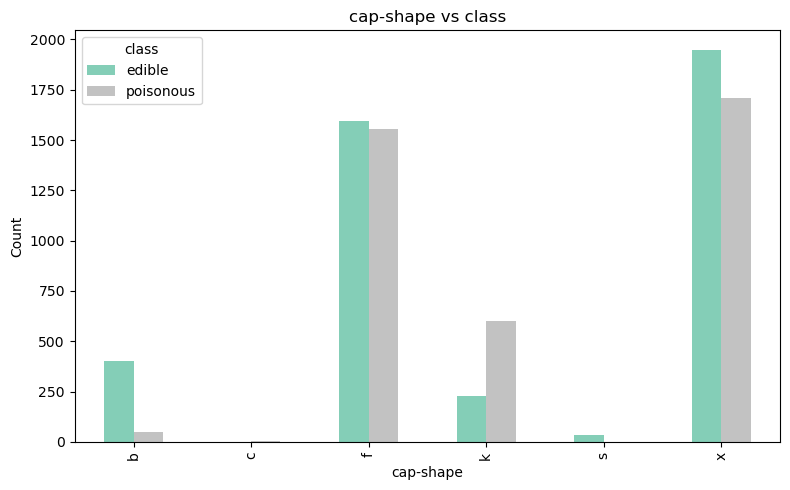

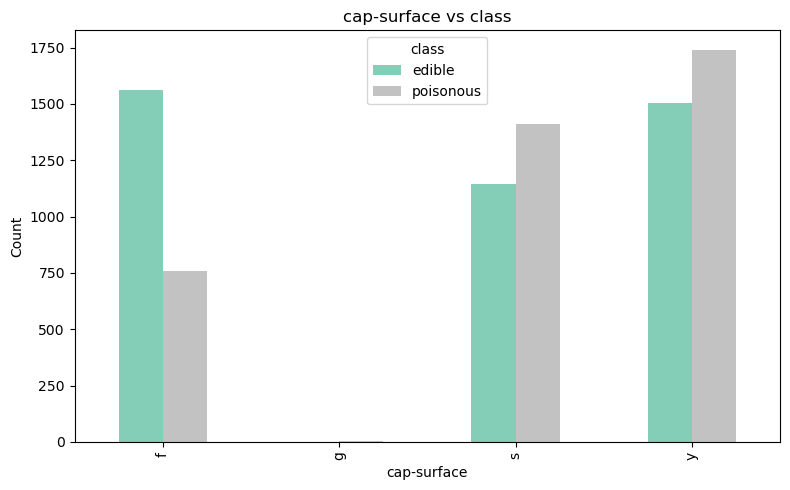

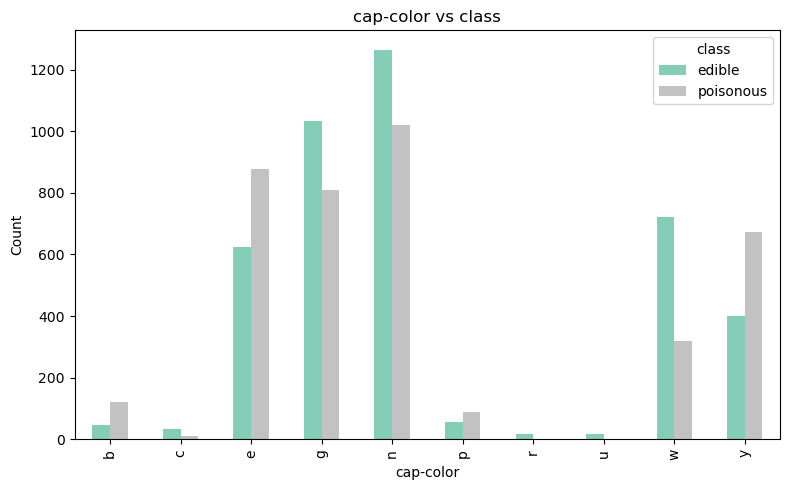

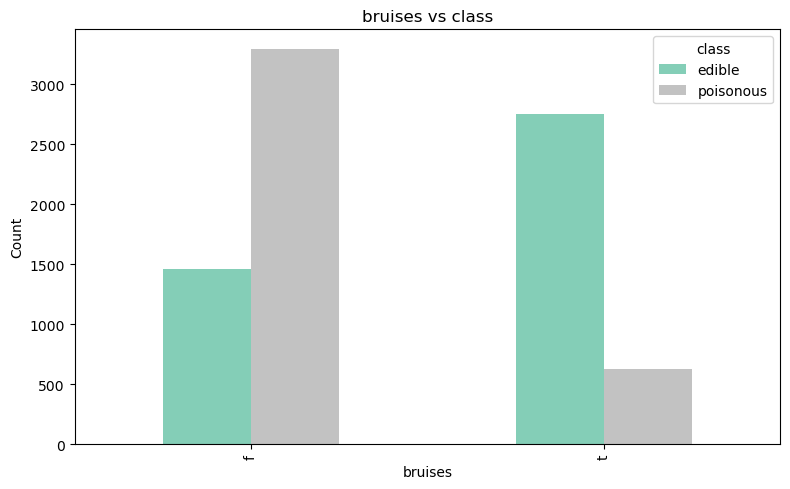

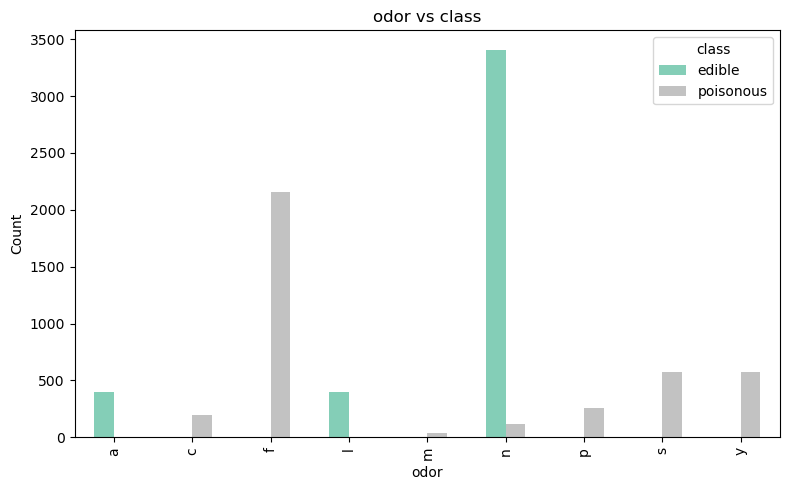

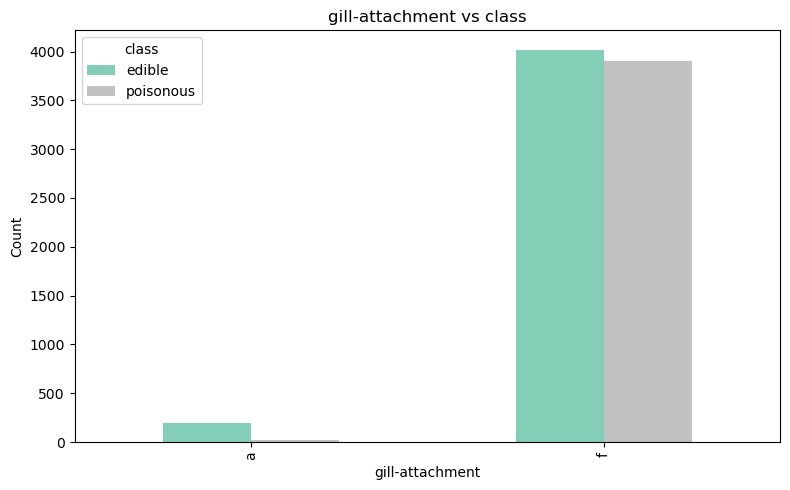

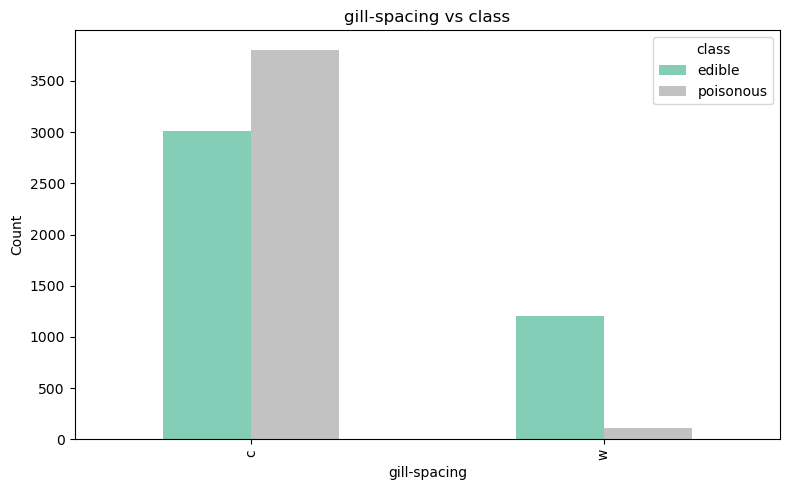

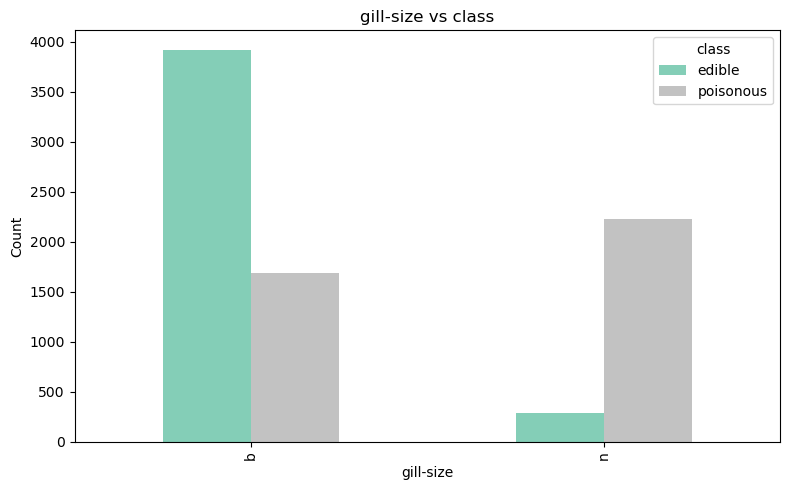

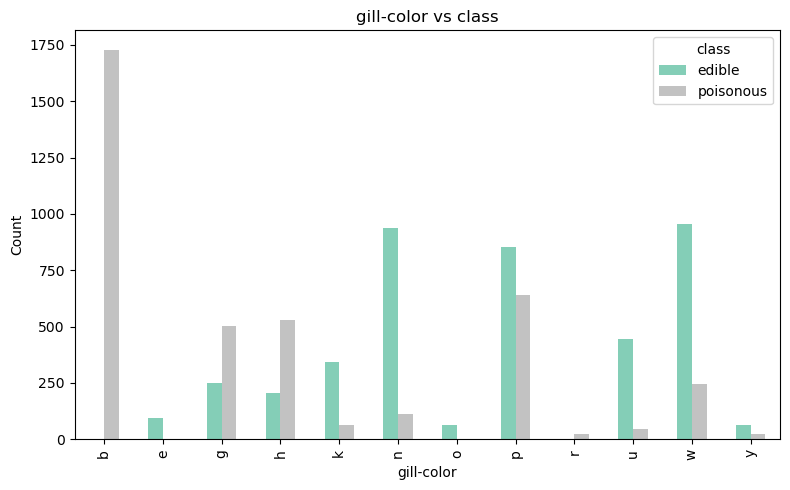

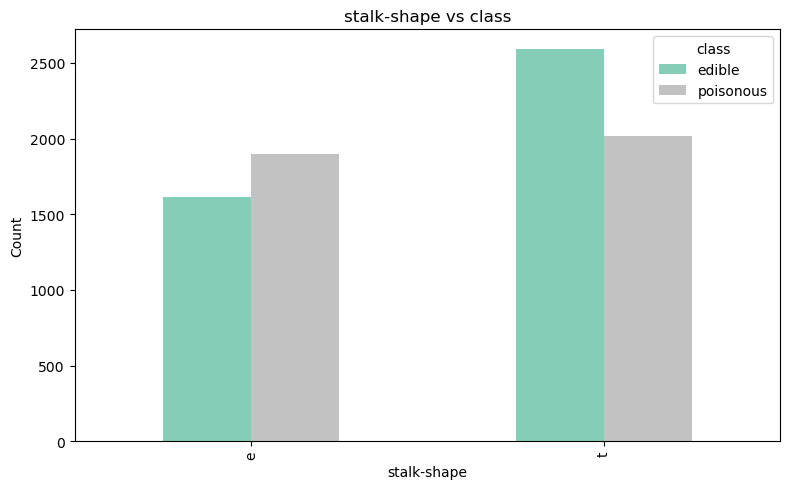

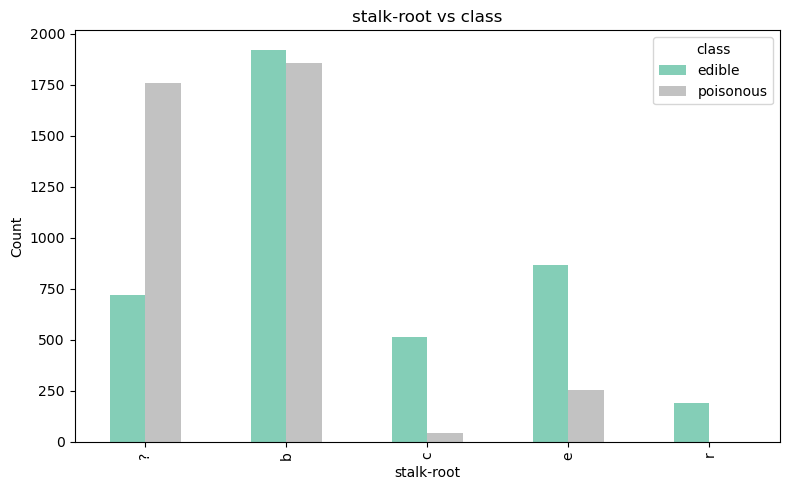

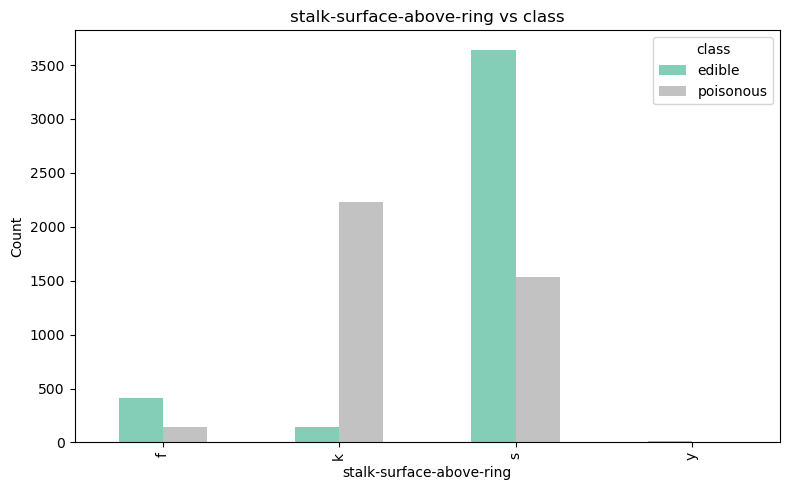

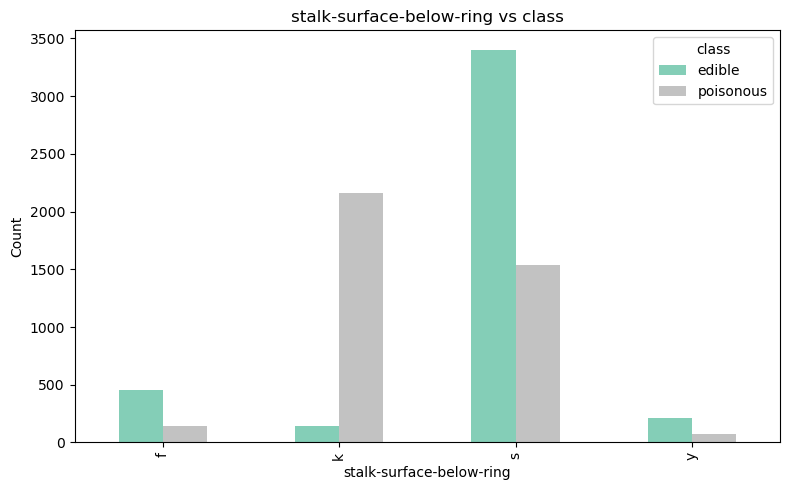

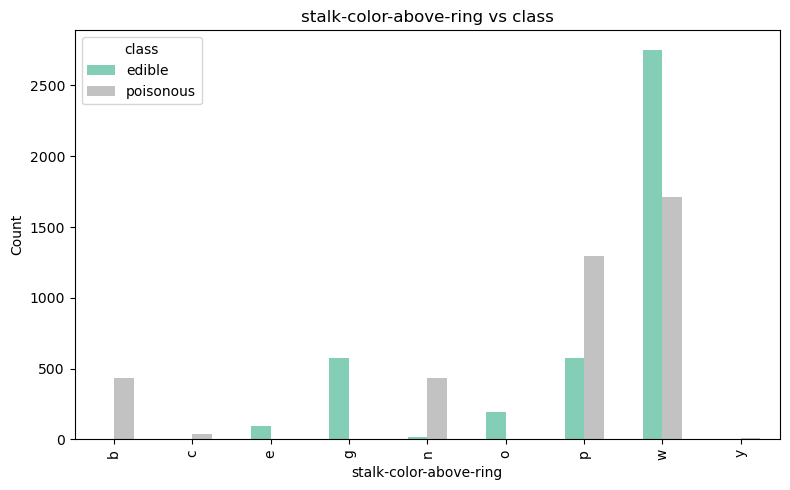

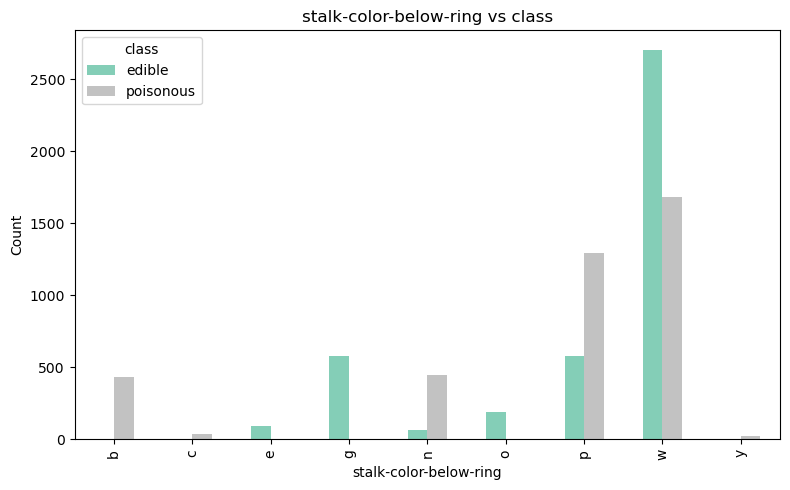

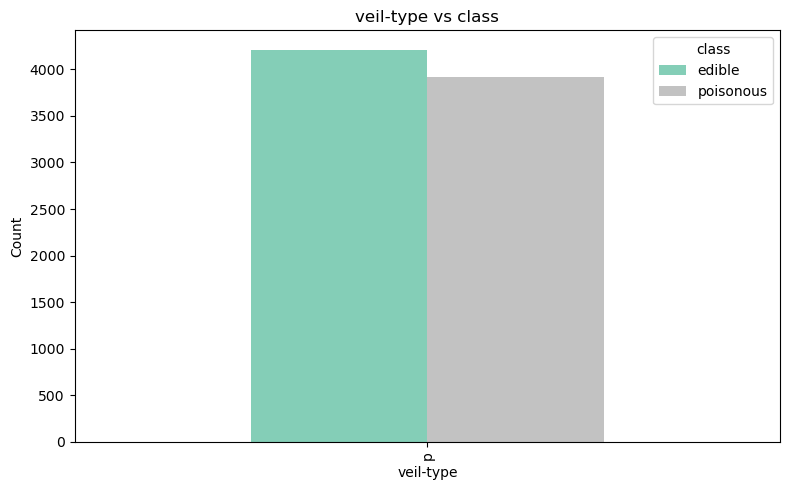

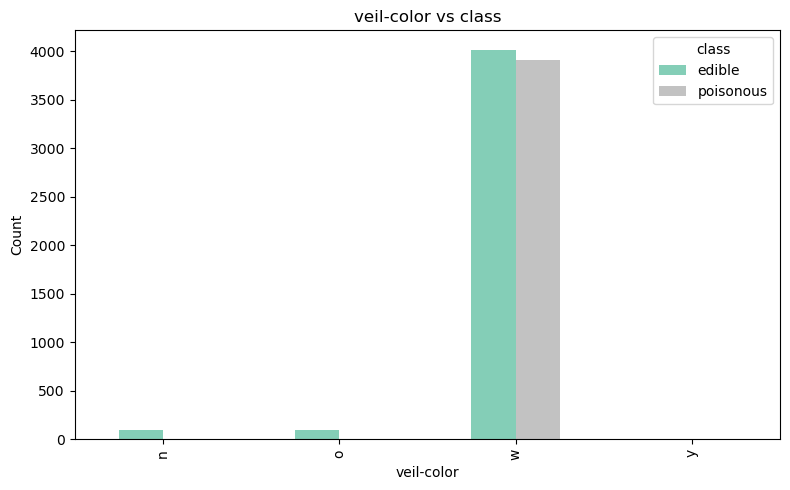

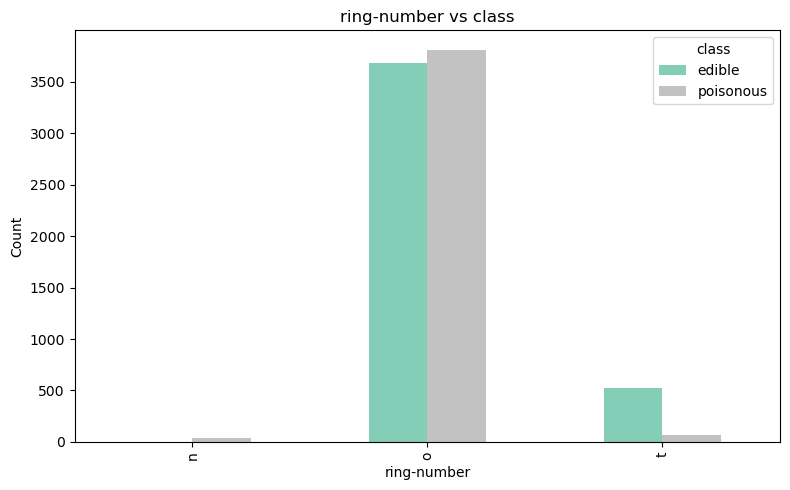

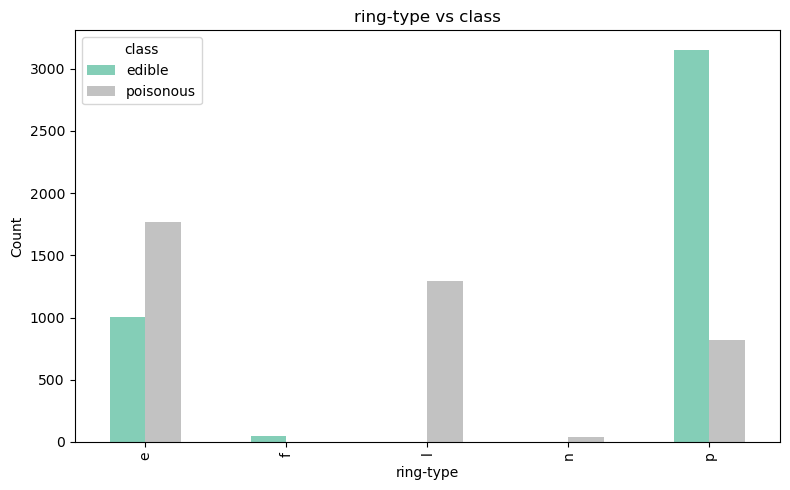

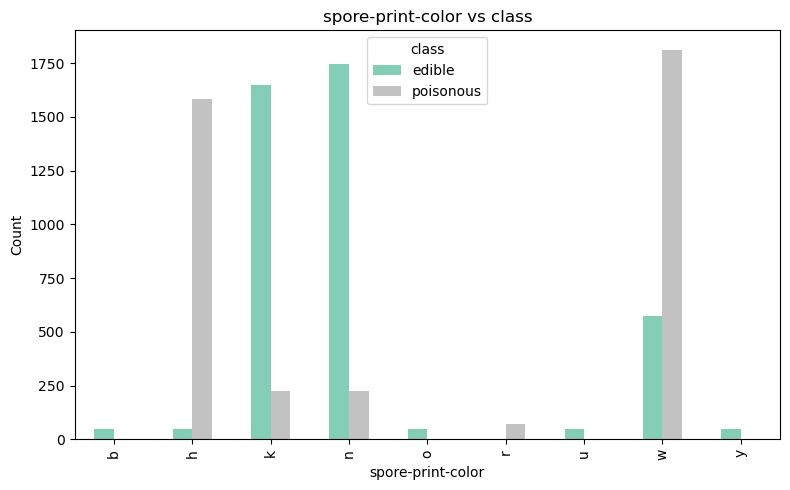

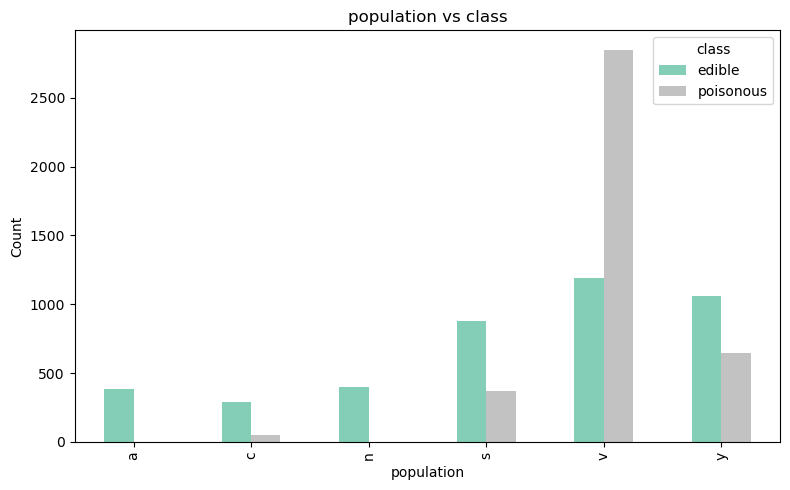

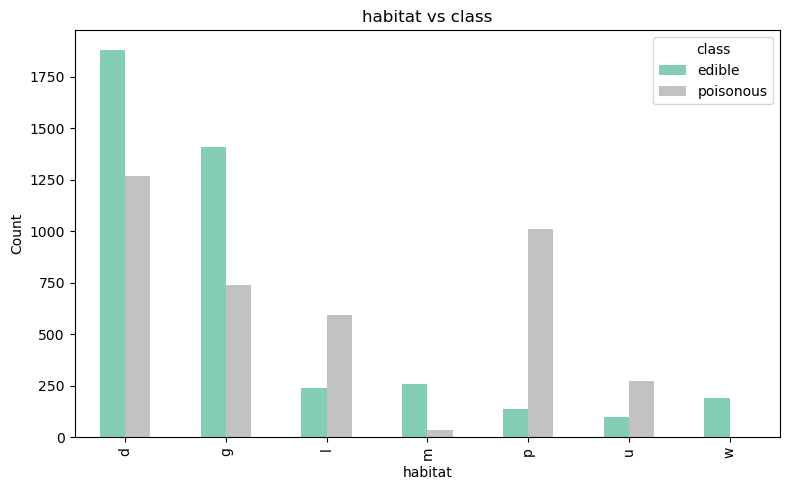

In [8]:
plot_feature_bars(df, stacked=False)

In [9]:
import numpy as np

def compute_log2_entropy(df, target='class'):
    entropies = {}

    for col in df.columns:
        if col == target:
            continue

        entropy = 0
        for category in df[col].unique():
            subset = df[df[col] == category][target]
            probs = subset.value_counts(normalize=True)
            entropy_category = -np.sum(probs * np.log2(probs))
            entropy += (len(subset) / len(df)) * entropy_category  

        entropies[col] = entropy

    entropy_series = pd.Series(entropies).sort_values(ascending=False)
    
    plt.figure(figsize=(10, 6))
    entropy_series.plot(kind='bar', color='skyblue')
    plt.title('Log₂ Entropy per Feature')
    plt.ylabel('Entropy')
    plt.xlabel('Feature')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return entropy_series


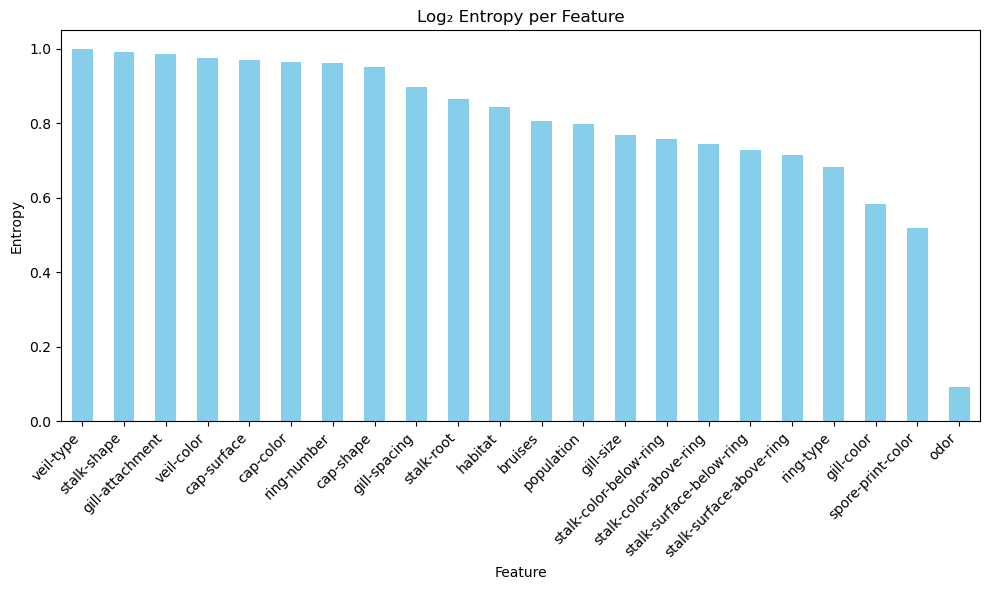

veil-type                   0.999068
stalk-shape                 0.991551
gill-attachment             0.984903
veil-color                  0.975251
cap-surface                 0.970478
cap-color                   0.963019
ring-number                 0.960615
cap-shape                   0.950271
gill-spacing                0.898185
stalk-root                  0.864250
habitat                     0.842234
bruises                     0.806688
population                  0.797110
gill-size                   0.768914
stalk-color-below-ring      0.757652
stalk-color-above-ring      0.745223
stalk-surface-below-ring    0.727173
stalk-surface-above-ring    0.714342
ring-type                   0.681046
gill-color                  0.582090
spore-print-color           0.518363
odor                        0.092993
dtype: float64

In [10]:
compute_log2_entropy(df)